In [43]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ GPU is available:", gpus)
else:
    print("❌ GPU not found. Check your CUDA/cuDNN installation.")
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Lambda
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Input, Concatenate, UpSampling2D

✅ GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [44]:
import os
xml_dir = './dataset/Marmot_data'
bmp_dir = './dataset/Marmot_data'

xml_files = [f for f in os.listdir(xml_dir) if f.endswith('.xml')]
valid_xml_files = [f for f in xml_files if os.path.exists(os.path.join(bmp_dir, f.replace('.xml', '.bmp')))]

# Now create dataset from valid XML files only
list_ds = tf.data.Dataset.from_tensor_slices([os.path.join(xml_dir, f) for f in valid_xml_files])


In [45]:
img_height, img_width = 256, 256

def normalize(input_image):
  input_image = tf.cast(input_image, tf.float32) / 255.0
  return input_image


def decode_img(img):
  # convert the compressed string to a 3D uint8 tensor
  img = tf.image.decode_bmp(img, channels=3)
  # resize the image to the desired size
  return tf.image.resize(img, [img_height, img_width])

def decode_mask_img(img):
  # convert the compressed string to a 2D uint8 tensor
  img = tf.image.decode_jpeg(img, channels=1)
  # resize the image to the desired size
  return tf.image.resize(img, [img_height, img_width])


def process_path(file_path):
  file_path = tf.strings.regex_replace(file_path, '.xml', '.bmp')

  mask_file_path = tf.strings.regex_replace(file_path, '.bmp', '.jpeg')

  table_mask_file_path = tf.strings.regex_replace(mask_file_path, 'Marmot_data', 'table_mask')
  column_mask_file_path = tf.strings.regex_replace(mask_file_path, 'Marmot_data', 'column_mask')

  img = normalize(decode_img(tf.io.read_file(file_path)))
  table_mask = normalize(decode_mask_img(tf.io.read_file(table_mask_file_path)))
  column_mask = normalize(decode_mask_img(tf.io.read_file(column_mask_file_path)))

  return img, {"table_output" : table_mask, "column_output" : column_mask }

In [46]:
# dataset = list_ds.map(process_path)

DATASET_SIZE = len(list(list_ds))
train_size = int(0.9 * DATASET_SIZE)
test_size = int(0.1 * DATASET_SIZE)

train = list_ds.take(train_size)
test = list_ds.skip(train_size)

TRAIN_LENGTH = len(list(train))
BATCH_SIZE = 2
BUFFER_SIZE = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

train = train.shuffle(BUFFER_SIZE)

train = train.map(process_path,
                      num_parallel_calls=tf.data.experimental.AUTOTUNE)

test = test.map(process_path)

train_dataset = train.batch(BATCH_SIZE).repeat().prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
test_dataset = test.batch(BATCH_SIZE)

In [47]:
def display(display_list):
  plt.figure(figsize=(15, 15))

  title = ['Input Image', 'Table Mask', 'Column Mask']

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
    plt.axis('off')
  plt.show()

(256, 256, 3)


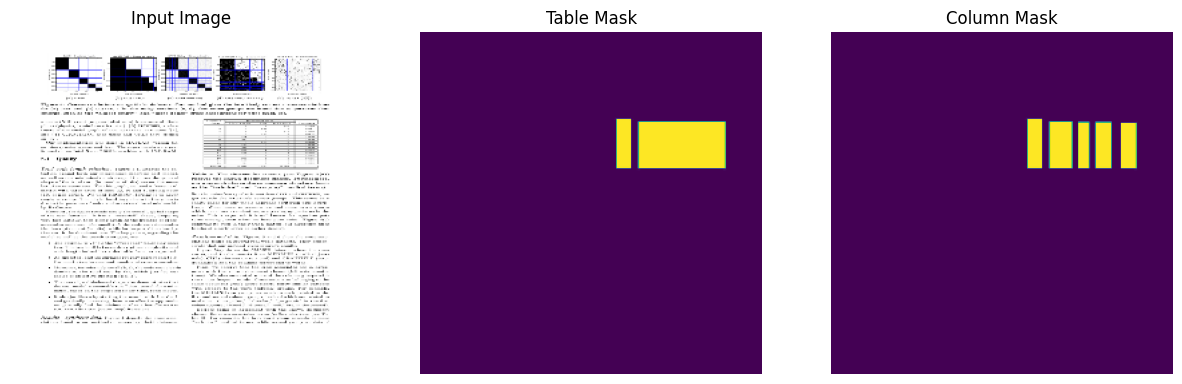

(256, 256, 3)


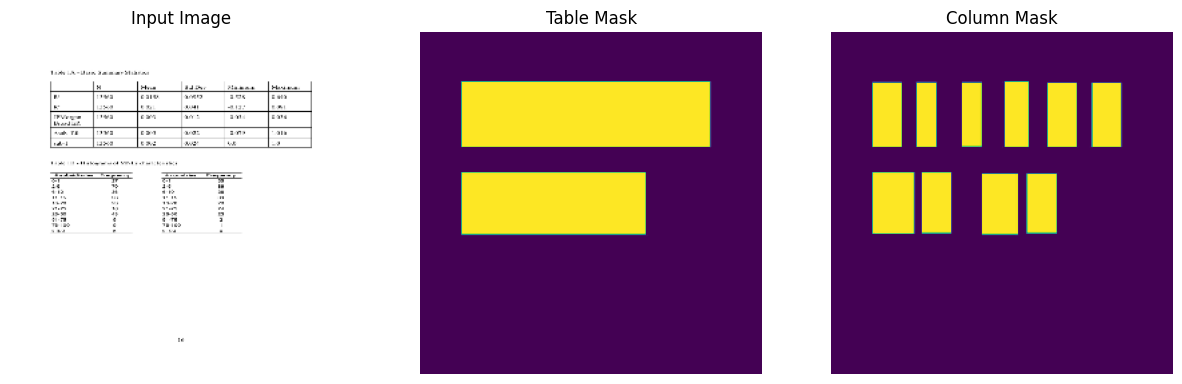

In [48]:
for image, mask  in train.take(2):
  print(image.shape)
  # print(mask.shape)
  display([image, mask['table_output'], mask['column_output']])

In [49]:
class TableNet:
  @staticmethod
  def build_table_decoder(inputs, pool3, pool4):
    x = Conv2D(512, (1, 1), activation = 'relu', name='conv7_table')(inputs)
    x = UpSampling2D(size=(2, 2))(x)

    concatenated = Concatenate()([x, pool4])

    # concatenated = concatenate([x, pool4])

    x = UpSampling2D(size=(2,2))(concatenated)
    
    concatenated = Concatenate()([x, pool3])

    x = UpSampling2D(size=(2,2))(concatenated)
    x = UpSampling2D(size=(2,2))(x)

    last = tf.keras.layers.Conv2DTranspose(
      3, 3, strides=2,
      padding='same', name='table_output') 
    
    x = last(x)

    return x

  @staticmethod
  def build_column_decoder(inputs, pool3, pool4):
    
    x = Conv2D(512, (1, 1), activation = 'relu', name='block7_conv1_column')(inputs)
    x = Dropout(0.8, name='block7_dropout_column')(x)

    x = Conv2D(512, (1, 1), activation = 'relu', name='block8_conv1_column')(x)
    x = UpSampling2D(size=(2, 2))(x)

    concatenated = Concatenate()([x, pool4])

    # concatenated = concatenate([x, pool4])

    x = UpSampling2D(size=(2,2))(concatenated)
    
    concatenated = Concatenate()([x, pool3])

    x = UpSampling2D(size=(2,2))(concatenated)
    x = UpSampling2D(size=(2,2))(x)

    last = tf.keras.layers.Conv2DTranspose(
      3, 3, strides=2,
      padding='same', name='column_output') 
    
    x = last(x)

    return x  

  @staticmethod
  def vgg_base(inputs):
    base_model = tf.keras.applications.vgg19.VGG19(
        input_shape=[256, 256, 3],
        include_top=False, weights='imagenet')
    
    layer_names = ['block3_pool', 'block4_pool', 'block5_pool']
    layers = [base_model.get_layer(name).output for name in layer_names]

    pool_layers_model = Model(inputs=base_model.input, outputs=layers, name='VGG-19')
    pool_layers_model.trainable = False

    return pool_layers_model(inputs)
  
  @staticmethod
  def build():
    inputShape = (256, 256, 3)

    inputs = Input(shape=inputShape, name='input')

    pool_layers = TableNet.vgg_base(inputs)

    x = Conv2D(512, (1, 1), activation = 'relu', name='block6_conv1')(pool_layers[2])
    x = Dropout(0.8, name='block6_dropout1')(x)
    x = Conv2D(512, (1, 1), activation = 'relu', name='block6_conv2')(x)
    x = Dropout(0.8, name = 'block6_dropout2')(x)
    
    table_mask = TableNet.build_table_decoder(x, pool_layers[0], pool_layers[1])
    column_mask = TableNet.build_column_decoder(x, pool_layers[0], pool_layers[1])

    model = Model(			
              inputs=inputs,
			        outputs=[table_mask, column_mask],
			        name="tablenet")
    
    return model

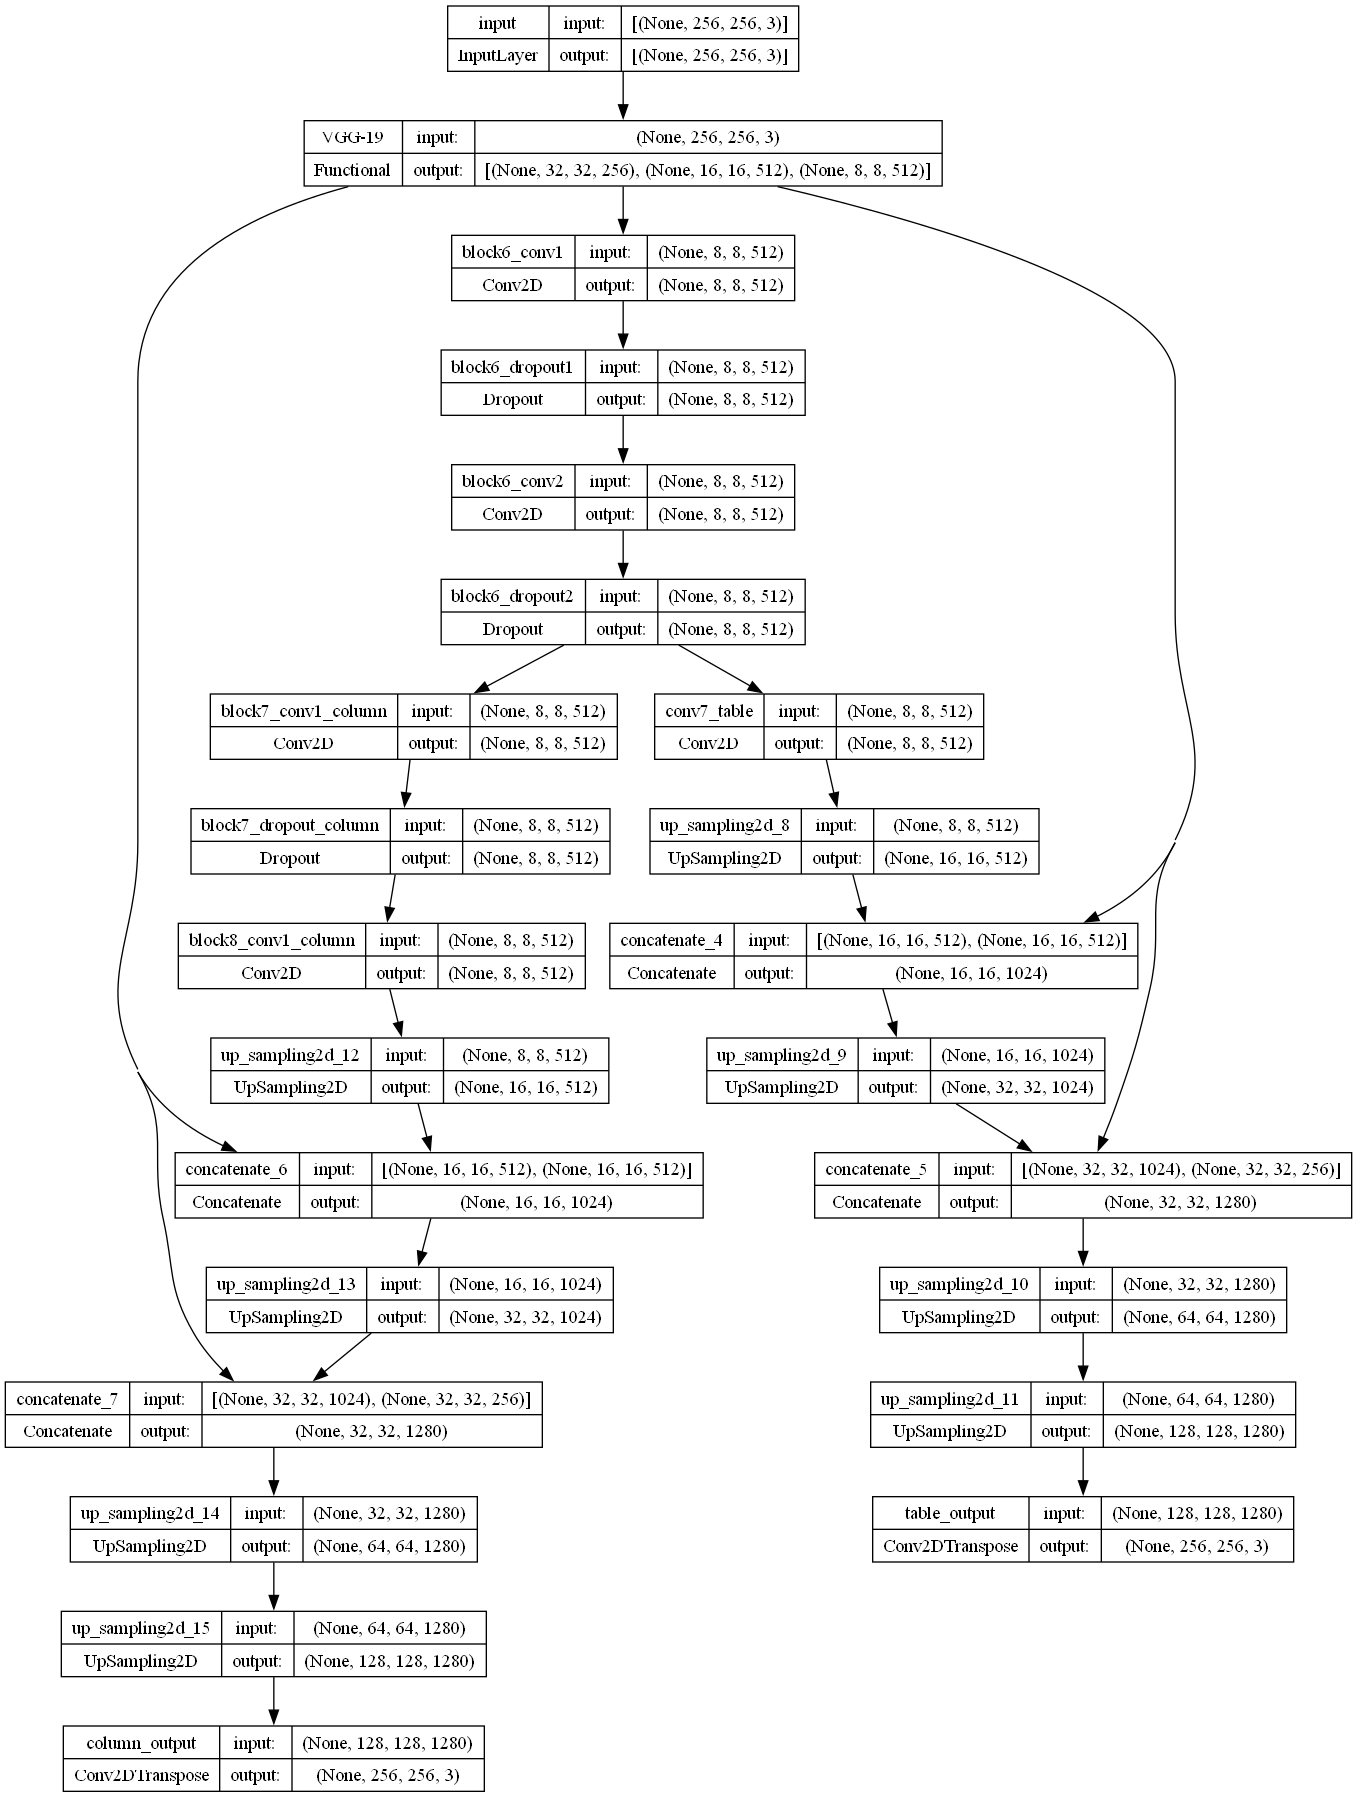

In [50]:
model = TableNet.build()
tf.keras.utils.plot_model(model, show_shapes=True)

In [51]:
losses = {
	"table_output": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
	"column_output": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
}

lossWeights = {"table_output": 1.0, "column_output": 1.0}

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, epsilon=1e-08),
              loss=losses,
              metrics=['accuracy'],
              loss_weights=lossWeights)

# model.compile(optimizer='adam',
#               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#               metrics=['accuracy'])

In [52]:
def create_mask(pred_mask1, pred_mask2):
  pred_mask1 = tf.argmax(pred_mask1, axis=-1)
  pred_mask1 = pred_mask1[..., tf.newaxis]


  pred_mask2 = tf.argmax(pred_mask2, axis=-1)
  pred_mask2 = pred_mask2[..., tf.newaxis]
  return pred_mask1[0], pred_mask2[0]


In [53]:
for image, mask in train_dataset.take(1):
  sample_image, sample_mask1, sample_mask2 = image, mask['table_output'], mask['column_output']

def show_predictions(dataset=None, num=1):
  if dataset:
    for image, (mask1, mask2) in dataset.take(num):
      pred_mask1, pred_mask2 = model.predict(image, verbose=1)
      table_mask, column_mask = create_mask(pred_mask1, pred_mask2)
      
      display([image[0], table_mask, column_mask])
  else:
    pred_mask1, pred_mask2 = model.predict(sample_image, verbose=1)
    table_mask, column_mask = create_mask(pred_mask1, pred_mask2)

    display([sample_image[0], table_mask, column_mask])

1/1 [==============================] - 0s 198ms/step


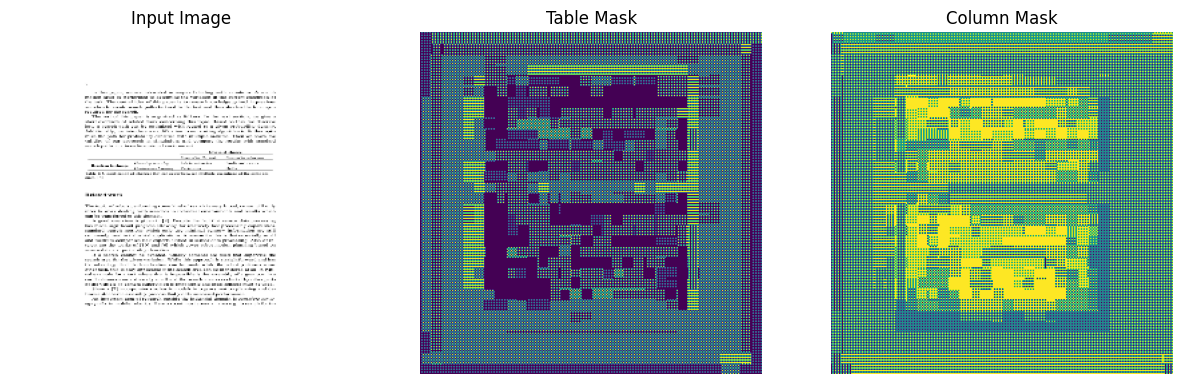

In [54]:
show_predictions()

In [55]:
from IPython.display import clear_output

class DisplayCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    clear_output(wait=True)
    show_predictions()
    print ('\nSample Prediction after epoch {}\n'.format(epoch+1))

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath="mymodel_{epoch}",
        save_best_only=True,
        monitor="val_loss",
        verbose=1,
    )

early_stoping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        verbose=1,
    )



1/1 [==============================] - 0s 21ms/step


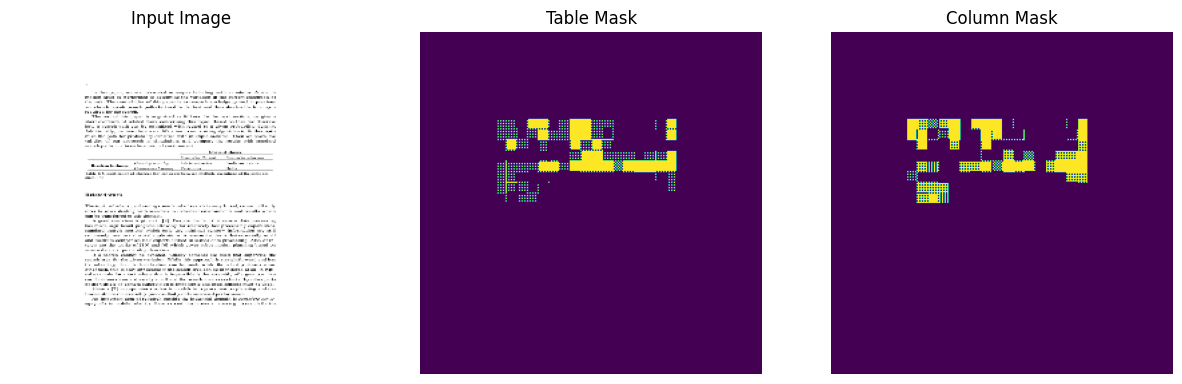


Sample Prediction after epoch 5000


Epoch 5000: val_loss did not improve from 0.29085
222/222 [==============================] - 9s 42ms/step - loss: 0.1810 - table_output_loss: 0.0787 - column_output_loss: 0.1024 - table_output_accuracy: 0.9571 - column_output_accuracy: 0.9311 - val_loss: 0.3969 - val_table_output_loss: 0.1895 - val_column_output_loss: 0.2074 - val_table_output_accuracy: 0.9387 - val_column_output_accuracy: 0.9124


In [56]:
EPOCHS = 5000
VAL_SUBSPLITS = 5
VALIDATION_STEPS = test_size//BATCH_SIZE//VAL_SUBSPLITS


model_history = model.fit(train_dataset, epochs=EPOCHS,
                          steps_per_epoch=STEPS_PER_EPOCH,
                          validation_steps=VALIDATION_STEPS,
                          validation_data=test_dataset,
                          callbacks=[DisplayCallback(), model_checkpoint])

1/1 [==============================] - 0s 22ms/step


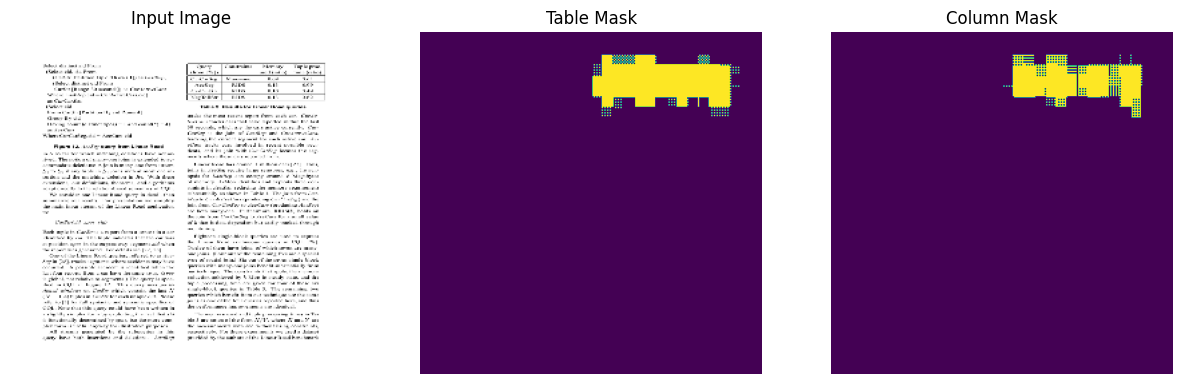

1/1 [==============================] - 0s 24ms/step


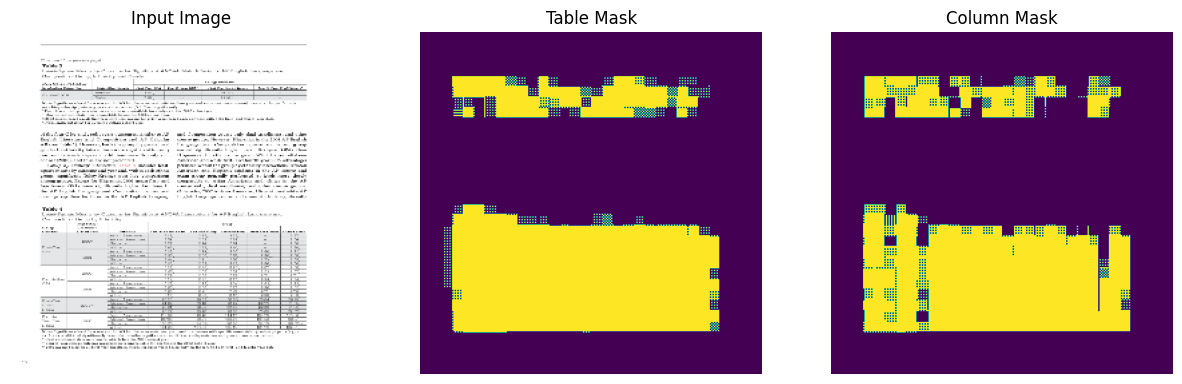

1/1 [==============================] - 0s 23ms/step


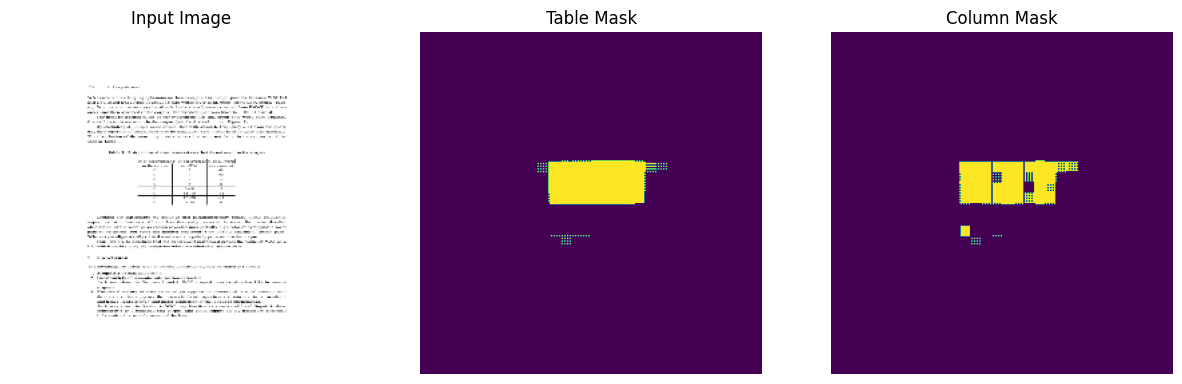

1/1 [==============================] - 0s 21ms/step


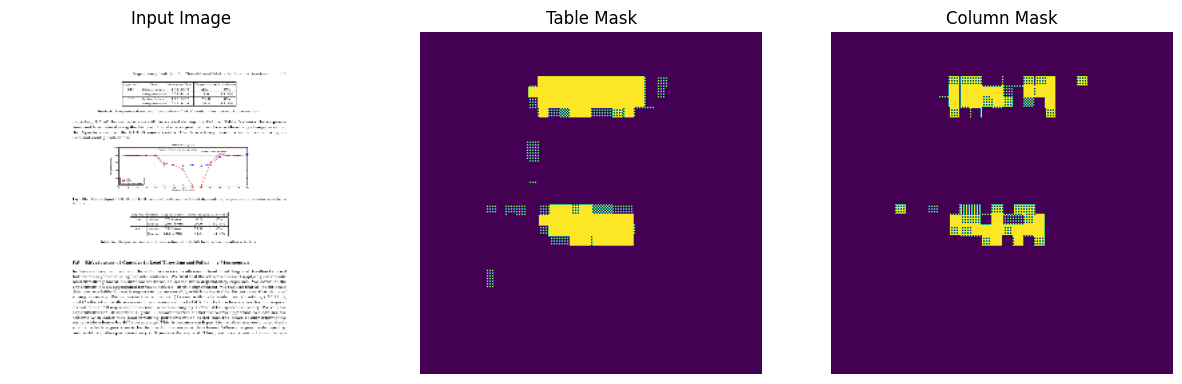

1/1 [==============================] - 0s 23ms/step


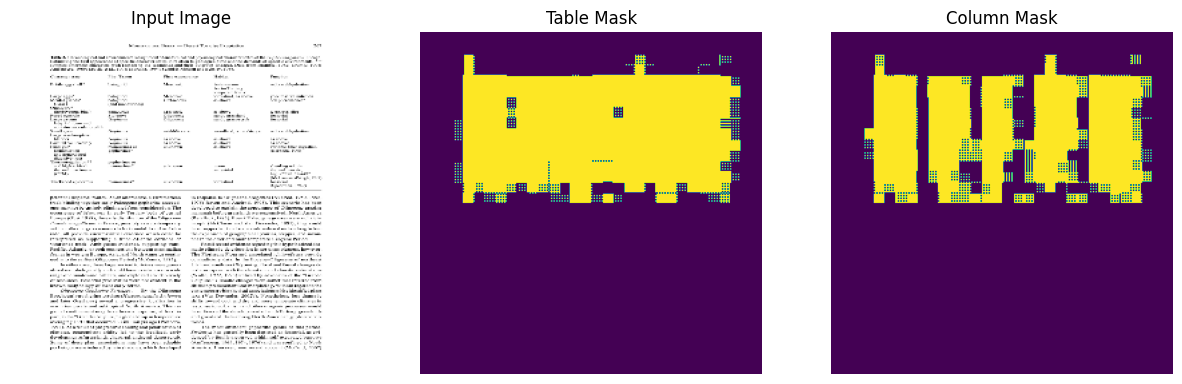

In [57]:
show_predictions(train_dataset, 5)

In [58]:
model.save('model_66')

INFO:tensorflow:Assets written to: model_66\assets


INFO:tensorflow:Assets written to: model_66\assets


In [59]:
from tensorflow.keras.models import load_model

model = load_model('model_66')

In [60]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model(dataset, model):
    y_true_table = []
    y_pred_table = []
    y_true_column = []
    y_pred_column = []

    for image_batch, mask_dict in dataset:
        # Get true masks and convert to numpy arrays
        true_table_mask = mask_dict['table_output'].numpy()
        true_column_mask = mask_dict['column_output'].numpy()
        
        # Predict using model
        pred_table_mask, pred_column_mask = model.predict(image_batch)
        
        # Reshape all masks to be 2D (height x width)
        true_table_mask = true_table_mask.reshape(-1)
        true_column_mask = true_column_mask.reshape(-1)
        pred_table_mask = pred_table_mask.reshape(-1, pred_table_mask.shape[-1])
        pred_column_mask = pred_column_mask.reshape(-1, pred_column_mask.shape[-1])
        
        # Convert predictions to class labels (0 or 1)
        pred_table_mask = np.argmax(pred_table_mask, axis=-1)
        pred_column_mask = np.argmax(pred_column_mask, axis=-1)
        
        # Threshold true masks in case they're float (0-1)
        true_table_mask = (true_table_mask > 0.5).astype(np.uint8)
        true_column_mask = (true_column_mask > 0.5).astype(np.uint8)
        
        y_true_table.extend(true_table_mask)
        y_pred_table.extend(pred_table_mask)
        y_true_column.extend(true_column_mask)
        y_pred_column.extend(pred_column_mask)

    # Calculate metrics
    table_recall = recall_score(y_true_table, y_pred_table)
    table_precision = precision_score(y_true_table, y_pred_table)
    table_f1 = f1_score(y_true_table, y_pred_table)
    
    column_recall = recall_score(y_true_column, y_pred_column)
    column_precision = precision_score(y_true_column, y_pred_column)
    column_f1 = f1_score(y_true_column, y_pred_column)

    # Print results in table format
    print("Model Evaluation Results")
    print("-------------------------------------------------")
    print("{:<40} {:<10} {:<10} {:<10}".format('Model', 'Recall', 'Precision', 'F1-Score'))
    print("-------------------------------------------------")
    print("{:<40} {:<10.4f} {:<10.4f} {:<10.4f}".format(
        'Table Detection', 
        table_recall, 
        table_precision, 
        table_f1))
    print("{:<40} {:<10.4f} {:<10.4f} {:<10.4f}".format(
        'Column Detection', 
        column_recall, 
        column_precision, 
        column_f1))
    print("-------------------------------------------------")

In [61]:
evaluate_model(test_dataset, model)


1/1 [==============================] - 0s 23ms/step
Model Evaluation Results
-------------------------------------------------
Model                                    Recall     Precision  F1-Score  
-------------------------------------------------
Table Detection                          0.7339     0.8631     0.7933    
Column Detection                         0.5751     0.7946     0.6673    
-------------------------------------------------


In [62]:
import shutil
shutil.make_archive('model66', 'zip', 'model_66')

'H:\\University works(NSU)\\CSE 465\\project\\TableNet-master\\model66.zip'

In [63]:
!copy model66.zip "H:\\University works(NSU)\\CSE 465\\project\\TableNet-master\\model"

        1 file(s) copied.


In [64]:
model = load_model('model_66')  # Your saved model

1/1 [==============================] - 0s 194ms/step


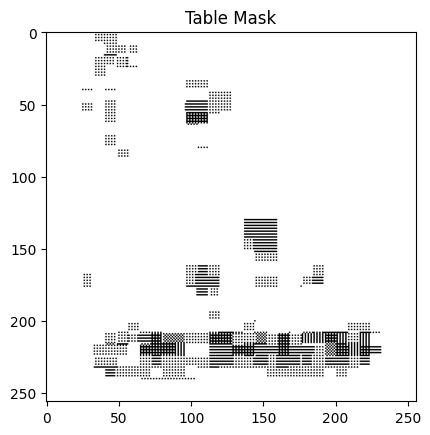

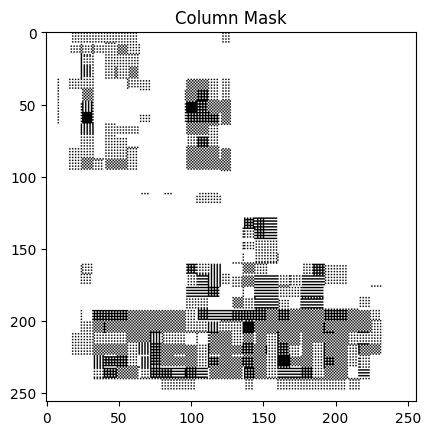

In [65]:
for image, mask in test_dataset.take(1):
    # Predict for a single image (use image[0] if batch_size > 1)
    pred_table_mask, pred_column_mask = model.predict(tf.expand_dims(image[0], axis=0))
    
    # Remove batch and channel dimensions (keep only H x W)
    table_mask = (pred_table_mask[0, ..., 0] > 0.5).astype(np.uint8)  # Shape: (256, 256)
    column_mask = (pred_column_mask[0, ..., 0] > 0.5).astype(np.uint8)
    
    # Display
    plt.imshow(table_mask, cmap='gray')
    plt.title("Table Mask")
    plt.show()
    
    plt.imshow(column_mask, cmap='gray')
    plt.title("Column Mask")
    plt.show()

In [66]:
import sys
!{sys.executable} -m pip install opencv-python

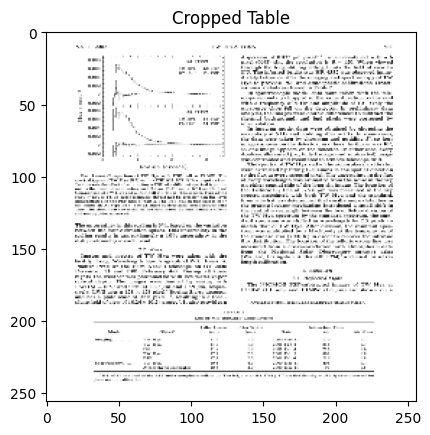

In [67]:
import cv2
import numpy as np

# Ensure table_mask is a numpy array with dtype=uint8
table_mask = table_mask.astype(np.uint8)

# Find contours
contours, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Get the largest contour
if contours:  # Check if contours were found
    table_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(table_contour)
    
    # Crop the table region
    table_roi = image[0].numpy()[y:y+h, x:x+w]
    plt.imshow(table_roi)
    plt.title("Cropped Table")
    plt.show()
else:
    print("No contours found in the mask!")